##### Ideal QSVM Optimization 

In [1]:
# ===================================================================
# QSVM HYPERPARAMETER OPTIMIZATION - SPAMBASE (SUBSET)
# ===================================================================

"""
This notebook systematically explores QSVM hyperparameters to identify
optimal configurations for the Spambase dataset.

Experiments:
- PCA dimensions: [4, 8, 12] → Qubit count
- Reps: [1, 2, 3] → Circuit depth
- Entanglement: ['linear', 'full'] → Feature correlations
- Shots: [256, 1024] → Sampling precision (ideal vs realistic)

Goal: Find configuration that maximizes test accuracy on 300-sample subset.
"""

"\nThis notebook systematically explores QSVM hyperparameters to identify\noptimal configurations for the Spambase dataset.\n\nExperiments:\n- PCA dimensions: [4, 8, 12] → Qubit count\n- Reps: [1, 2, 3] → Circuit depth\n- Entanglement: ['linear', 'full'] → Feature correlations\n- Shots: [256, 1024] → Sampling precision (ideal vs realistic)\n\nGoal: Find configuration that maximizes test accuracy on 300-sample subset.\n"

In [ ]:
# Imports
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, classification_report, balanced_accuracy_score

In [3]:
# Qiskit Imports
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.utils import algorithm_globals

In [4]:
# Set seed for reproducibility
algorithm_globals.random_seed = 12345
np.random.seed(12345)

##### Data Loading and Prepocessing

In [5]:
# --- Import Spambase Column Names ---
spambase_columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_;",
    "char_freq_(",
    "char_freq_[",
    "char_freq_!",
    "char_freq_$",
    "char_freq_#",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    # finally the target label column:
    "label"
]

# --- 1. Load the Spambase Dataset ---
file_path = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\spambase\spambase.data'
df = pd.read_csv(file_path, header=None, names=spambase_columns)
df.drop_duplicates(inplace=True)

In [6]:
# 2. Some basic processing
print(f"Original shape of Spambase data: {df.shape}") # Prints original dataset shape
df.drop_duplicates(inplace=True) # Remove duplicates
print(f"Shape after dropping duplicates: {df.shape}\n") # Then print again the new shape

Original shape of Spambase data: (4210, 58)
Shape after dropping duplicates: (4210, 58)



In [7]:
# Split features and target
X = df.drop('label', axis=1)
y = df['label']

# Create subset (300 samples)
X_subset, _, y_subset, _ = train_test_split(
    X, y, train_size=429, stratify=y, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.30, random_state=42, stratify=y_subset
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}\n")

Training samples: 300
Test samples: 129



In [8]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [9]:
# --- Feature Correlation Analysis ---
print("=" * 70)
print("Feature Correlation Analysis")
print("=" * 70)

THRESH = 0.9

THRESH = 0.9
corr_matrix = X_train_scaled_df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

columns_to_drop = set()
for column in upper_triangle.columns:
    high_corr_partners = upper_triangle.index[upper_triangle[column] > THRESH].tolist()
    if high_corr_partners:
        for partner in high_corr_partners:
            corr_main = y_train.corr(X_train_scaled_df[column])
            corr_partner = y_train.corr(X_train_scaled_df[partner])
            if abs(corr_main) < abs(corr_partner):
                columns_to_drop.add(column)
            else:
                columns_to_drop.add(partner)

to_drop_final = sorted(list(columns_to_drop))
X_train_selected = X_train_scaled_df.drop(columns=to_drop_final)
X_test_selected = X_test_scaled_df.drop(columns=to_drop_final)

print(f"Features after selection: {X_train_selected.shape[1]}\n")

Feature Correlation Analysis
Features after selection: 56



c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# ===================================================================
# OPTIMIZATION EXPERIMENT CONFIGURATION
# ===================================================================
print("=" * 80)
print("HYPERPARAMETER OPTIMIZATION GRID")
print("=" * 80)

# Define parameter grid
PCA_DIMS = [4, 8, 12]          # Qubit counts
REPS = [1, 2, 3]                # Circuit depths
ENTANGLEMENTS = ['linear', 'full']  # Entanglement topologies
SHOTS = [256, 512, 1024]            # Start with 256 and end at 1024
# C_VALUE = 0.1                   # Fixed C for speed (or use grid search)

# Calculate total experiments
total_experiments = len(PCA_DIMS) * len(REPS) * len(ENTANGLEMENTS) * len(SHOTS)
print(f"Total configurations to test: {total_experiments}\n")

# Results storage
results = []

HYPERPARAMETER OPTIMIZATION GRID
Total configurations to test: 54



In [11]:
# ===================================================================
# OPTIMIZATION LOOP (WITH HYPERPARAMETER TUNING)
# ===================================================================

from sklearn.model_selection import GridSearchCV

experiment_num = 0

for pca_dim, reps, entanglement, shots in product(PCA_DIMS, REPS, ENTANGLEMENTS, SHOTS):
    experiment_num += 1
    
    print("=" * 80)
    print(f"EXPERIMENT {experiment_num}/{total_experiments}")
    print(f"  PCA Dims (Qubits): {pca_dim}")
    print(f"  Reps: {reps}")
    print(f"  Entanglement: {entanglement}")
    print(f"  Shots: {shots}")
    print("=" * 80)
    
    try:
        # --- Apply PCA ---
        pca = PCA(n_components=pca_dim, random_state=42)
        X_train_pca = pca.fit_transform(X_train_selected)
        X_test_pca = pca.transform(X_test_selected)
        
        print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.4f}")
        
        # --- Create Quantum Kernel ---
        fm = ZZFeatureMap(
            feature_dimension=pca_dim,
            reps=reps,
            entanglement=entanglement
        )
        
        sampler = Sampler(default_shots=shots)
        fidelity = ComputeUncompute(sampler=sampler)
        qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=fm)
        
        # --- Compute Kernel Matrices ---
        print("Computing kernel matrices...")
        start_kernel = time.time()
        
        K_train = qkernel.evaluate(x_vec=X_train_pca)
        K_test = qkernel.evaluate(x_vec=X_test_pca, y_vec=X_train_pca)
        
        kernel_time = time.time() - start_kernel
        print(f"Kernel computation: {kernel_time:.2f}s")
        
        # --- GRID SEARCH FOR OPTIMAL C ---
        print("Grid searching for optimal C...")
        start_train = time.time()
        
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100]
            # No class_weight here
        }
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        
        grid_search = GridSearchCV(
            SVC(kernel='precomputed', class_weight='balanced'), 
            param_grid,
            cv=cv,
            scoring='accuracy',
            n_jobs=-1
        )
        
        grid_search.fit(K_train, y_train)
        best_svm = grid_search.best_estimator_
        best_C = grid_search.best_params_['C']
        cv_score = grid_search.best_score_
        
        train_time = time.time() - start_train
        
        print(f"  → Best C: {best_C}")
        print(f"  → CV Score: {cv_score:.4f}")
        print(f"  → Training time: {train_time:.2f}s")
        
        # --- Evaluate ---
        y_train_pred = best_svm.predict(K_train)
        y_test_pred = best_svm.predict(K_test)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
        spam_recall = recall_score(y_test, y_test_pred, pos_label=1)
        gen_gap = abs(train_acc - test_acc)
        
        print(f"  → Train Accuracy: {train_acc:.4f}")
        print(f"  → Test Accuracy: {test_acc:.4f}")
        print(f"  → Test Balanced Accuracy: {test_bal_acc:.4f}")
        print(f"  → Generalization Gap: {gen_gap:.4f}")
        print(f"  → Spam Recall: {spam_recall:.4f}\n")
        
        # --- Store Results ---
        results.append({
            'PCA_Dimension': pca_dim,
            'Reps': reps,
            'Entanglement': entanglement,
            'Shots': shots,
            'Best_C': best_C, 
            'CV_Score': cv_score,  
            'Train_Acc': train_acc,
            'Test_Acc': test_acc,
            'Test_Balanced_Acc': test_bal_acc,
            'Spam_Recall': spam_recall,
            'Generalization_Gap': gen_gap,
            'Kernel_Time': kernel_time,
            'Train_Time': train_time,
            'Total_Time': kernel_time + train_time,
            'Variance_Explained': pca.explained_variance_ratio_.sum(),
            'Status': 'Success'
        })
        
    except Exception as e:
        print(f"ERROR: {str(e)}\n")
        results.append({
            'PCA_Dimension': pca_dim,
            'Reps': reps,
            'Entanglement': entanglement,
            'Shots': shots,
            'Best_C': np.nan,
            'CV_Score': np.nan,
            'Train_Acc': np.nan,
            'Test_Acc': np.nan,
            'Test_Balanced_Acc': np.nan,
            'Spam_Recall': np.nan,
            'Generalization_Gap': np.nan,
            'Kernel_Time': np.nan,
            'Train_Time': np.nan,
            'Total_Time': np.nan,
            'Variance_Explained': np.nan,
            'Status': f'Failed: {str(e)}'
        })


EXPERIMENT 1/54
  PCA Dims (Qubits): 4
  Reps: 1
  Entanglement: linear
  Shots: 256
PCA variance explained: 0.2315
Computing kernel matrices...
Kernel computation: 380.30s
Grid searching for optimal C...
  → Best C: 100
  → CV Score: 0.6100
  → Training time: 14.09s
  → Train Accuracy: 1.0000
  → Test Accuracy: 0.5349
  → Test Balanced Accuracy: 0.5136
  → Generalization Gap: 0.4651
  → Spam Recall: 0.4118

EXPERIMENT 2/54
  PCA Dims (Qubits): 4
  Reps: 1
  Entanglement: linear
  Shots: 512
PCA variance explained: 0.2315
Computing kernel matrices...
Kernel computation: 774.42s
Grid searching for optimal C...
  → Best C: 10
  → CV Score: 0.6233
  → Training time: 15.76s
  → Train Accuracy: 0.9533
  → Test Accuracy: 0.5969
  → Test Balanced Accuracy: 0.5954
  → Generalization Gap: 0.3564
  → Spam Recall: 0.5882

EXPERIMENT 3/54
  PCA Dims (Qubits): 4
  Reps: 1
  Entanglement: linear
  Shots: 1024
PCA variance explained: 0.2315
Computing kernel matrices...
Kernel computation: 410.83s
Gri

In [12]:
# ===================================================================
# RESULTS ANALYSIS
# ===================================================================

print("\n" + "=" * 80)
print("OPTIMIZATION RESULTS SUMMARY")
print("=" * 80)

df_results = pd.DataFrame(results)

# Display all results sorted by test accuracy
df_sorted = df_results.sort_values('Test_Acc', ascending=False)
print("\nAll Configurations (sorted by Test Accuracy):")
print(df_sorted[['PCA_Dimension', 'Reps', 'Entanglement', 'Test_Acc', 'Generalization_Gap', 'Total_Time']].to_string(index=False))


# Find best configuration
best_idx = df_results['Test_Acc'].idxmax()
best_config = df_results.loc[best_idx]

print("\n" + "=" * 80)
print("BEST CONFIGURATION")
print("=" * 80)
print(f"PCA Dimensions (Qubits): {best_config['PCA_Dimension']}")
print(f"Reps: {best_config['Reps']}")
print(f"Entanglement: {best_config['Entanglement']}")
print(f"Shots: {best_config['Shots']}")
print(f"---")
print(f"Test Accuracy: {best_config['Test_Acc']:.4f}")
print(f"Train Accuracy: {best_config['Train_Acc']:.4f}")
print(f"Generalization Gap: {best_config['Generalization_Gap']:.4f}")
print(f"Spam Recall: {best_config['Spam_Recall']:.4f}")
print(f"Total Time: {best_config['Total_Time']:.1f}s")

# Save results
df_results.to_csv('qsvm_optimization_results.csv', index=False)
print("\n✓ Results saved to 'qsvm_optimization_results.csv'")



OPTIMIZATION RESULTS SUMMARY

All Configurations (sorted by Test Accuracy):
 PCA_Dimension  Reps Entanglement  Test_Acc  Generalization_Gap   Total_Time
             8     1         full  0.651163            0.348837   776.591163
             8     1         full  0.635659            0.364341   825.259974
             8     1         full  0.635659            0.364341   925.130976
             8     2         full  0.620155            0.379845  1328.895428
             4     1       linear  0.620155            0.329845   415.484386
             8     2         full  0.612403            0.387597  1270.680426
            12     1       linear  0.612403            0.387597  4549.140620
            12     1       linear  0.612403            0.387597  2048.888711
            12     2       linear  0.612403            0.387597  3070.263608
            12     2       linear  0.612403            0.387597  3042.219753
            12     3       linear  0.612403            0.387597  6328.167839

In [13]:
# ===================================================================
# BEST CONFIGURATION - DETAILED EVALUATION
# ===================================================================

print("\n" + "=" * 80)
print("BEST CONFIGURATION - DETAILED EVALUATION")
print("=" * 80)

best_idx = df_results['Test_Balanced_Acc'].idxmax()  # Pick best by balanced accuracy
best_row = df_results.loc[best_idx]

# Re-run best config to get classification report
pca_best = PCA(n_components=int(best_row['PCA_Dimension']), random_state=42)
X_train_pca_best = pca_best.fit_transform(X_train_selected)
X_test_pca_best = pca_best.transform(X_test_selected)

fm_best = ZZFeatureMap(
    feature_dimension=int(best_row['PCA_Dimension']),
    reps=int(best_row['Reps']),
    entanglement=best_row['Entanglement']
)
sampler_best = Sampler(default_shots=int(best_row['Shots']))
fidelity_best = ComputeUncompute(sampler=sampler_best)
qkernel_best = FidelityQuantumKernel(fidelity=fidelity_best, feature_map=fm_best)

K_train_best = qkernel_best.evaluate(x_vec=X_train_pca_best)
K_test_best = qkernel_best.evaluate(x_vec=X_test_pca_best, y_vec=X_train_pca_best)

svm_best = SVC(kernel='precomputed', class_weight='balanced', C=best_row['Best_C'])
svm_best.fit(K_train_best, y_train)

y_test_pred_best = svm_best.predict(K_test_best)

print(f"\nConfiguration:")
print(f"  PCA Dims: {int(best_row['PCA_Dimension'])}")
print(f"  Reps: {int(best_row['Reps'])}")
print(f"  Entanglement: {best_row['Entanglement']}")
print(f"  Shots: {int(best_row['Shots'])}")
print(f"  Best C: {best_row['Best_C']}")
print(f"\nPerformance:")
print(f"  Test Accuracy: {best_row['Test_Acc']:.4f}")
print(f"  Test Balanced Accuracy: {best_row['Test_Balanced_Acc']:.4f}")
print(f"  Spam Recall: {best_row['Spam_Recall']:.4f}")
print(f"  Generalization Gap: {best_row['Generalization_Gap']:.4f}")
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_best, zero_division=0))



BEST CONFIGURATION - DETAILED EVALUATION

Configuration:
  PCA Dims: 4
  Reps: 1
  Entanglement: linear
  Shots: 1024
  Best C: 10.0

Performance:
  Test Accuracy: 0.6202
  Test Balanced Accuracy: 0.6214
  Spam Recall: 0.6275
  Generalization Gap: 0.3298

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.66      0.51      0.58        78
           1       0.44      0.59      0.50        51

    accuracy                           0.54       129
   macro avg       0.55      0.55      0.54       129
weighted avg       0.57      0.54      0.55       129




GENERATING VISUALIZATIONS
✓ Saved: heatmap_test_accuracy.png


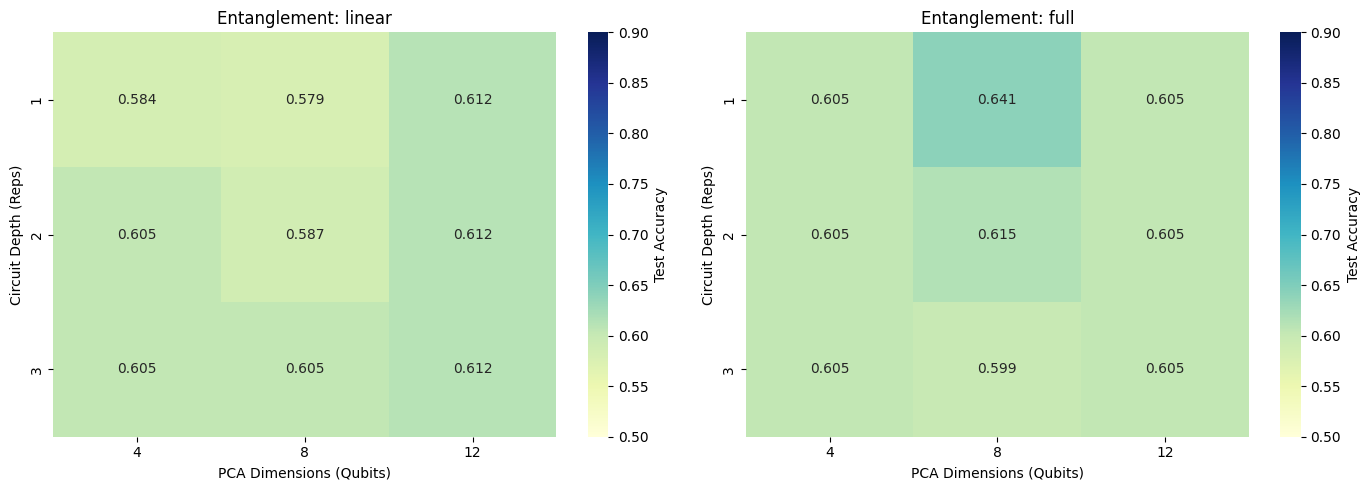

✓ Saved: bar_test_accuracy.png


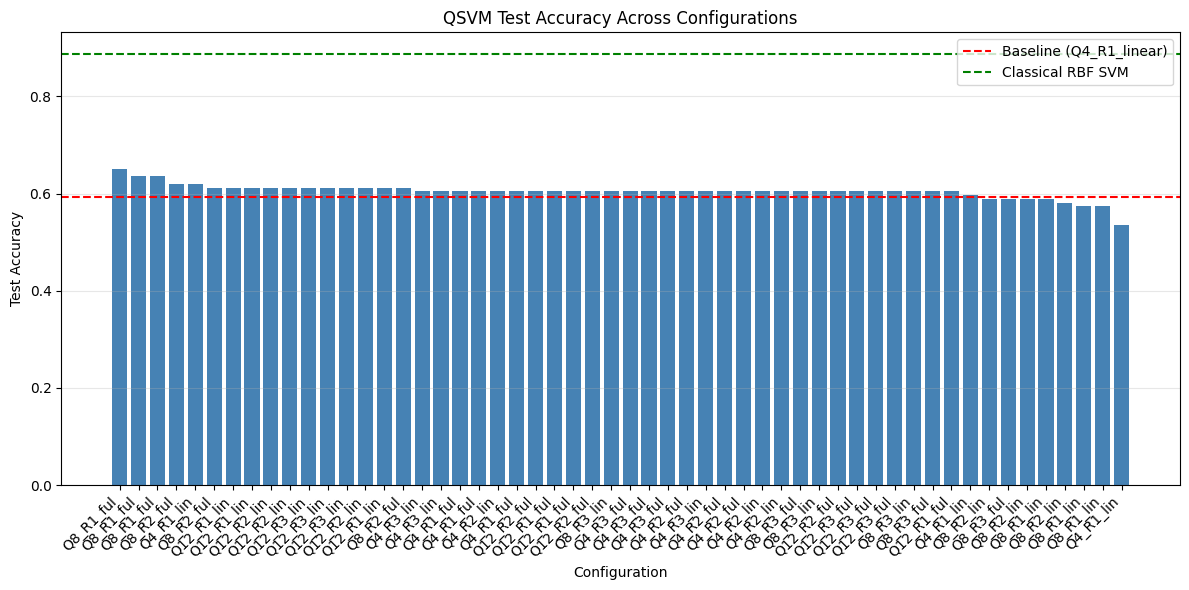

✓ Saved: scatter_accuracy_vs_time.png


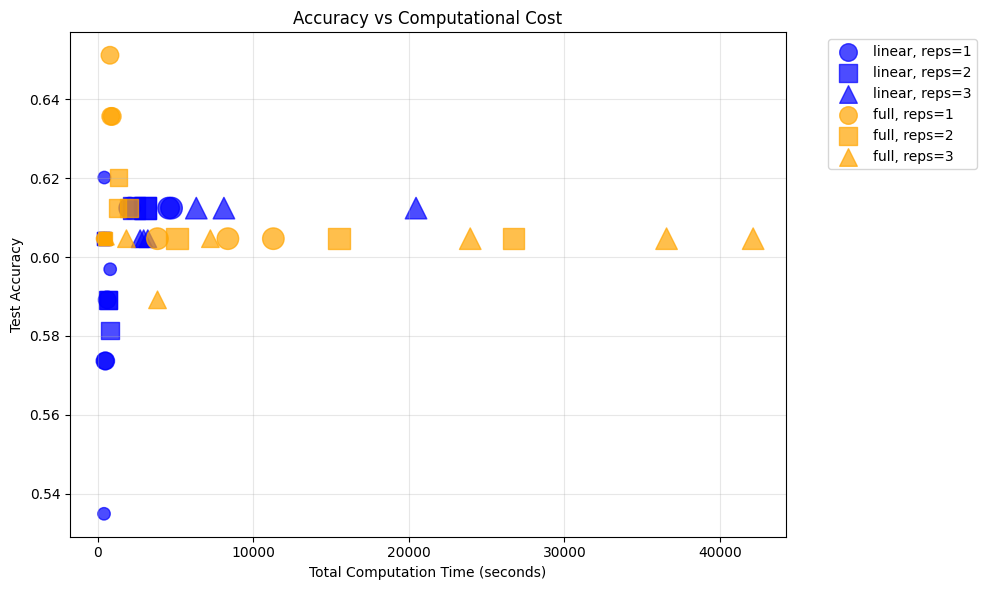

✓ Saved: line_pca_effect.png


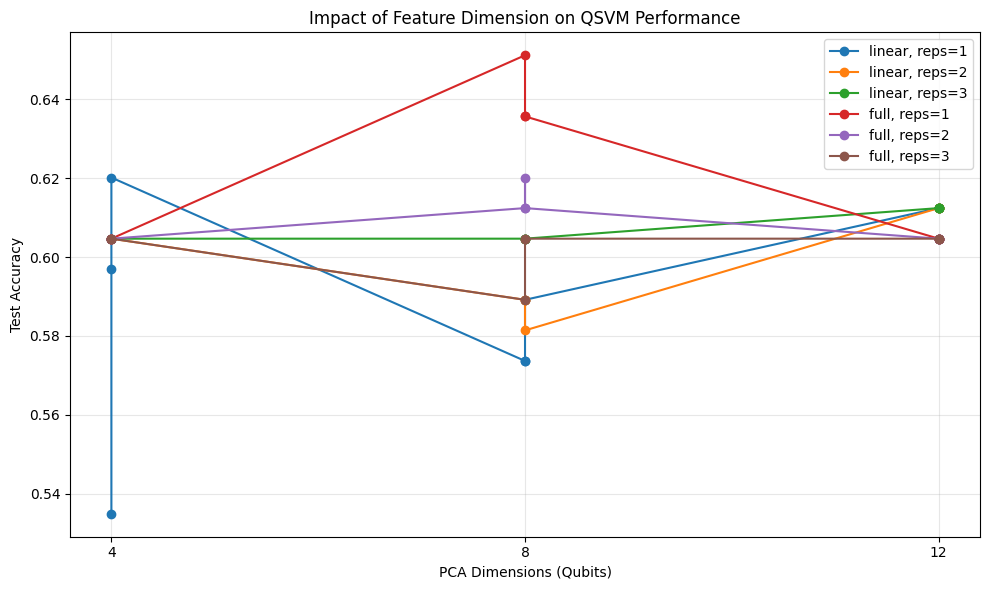


OPTIMIZATION COMPLETE!
Best Test Accuracy: 0.6512
Improvement over baseline: 0.0590 (10.0%)
Gap to Classical SVM: 0.2364


In [14]:
# ===================================================================
# VISUALIZATIONS
# ===================================================================

print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

# Filter successful experiments
df_success = df_results[df_results['Status'] == 'Success'].copy()

# 1. Heatmap: Test Accuracy vs PCA Dims & Reps (for each entanglement)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, ent in enumerate(['linear', 'full']):
    df_ent = df_success[df_success['Entanglement'] == ent]
    
    pivot = df_ent.pivot_table(
        values='Test_Acc',
        index='Reps',
        columns='PCA_Dimension',
        aggfunc='mean'
    )
    
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.3f',
        cmap='YlGnBu',
        cbar_kws={'label': 'Test Accuracy'},
        ax=axes[idx],
        vmin=0.5,
        vmax=0.9
    )
    
    axes[idx].set_title(f'Entanglement: {ent}')
    axes[idx].set_xlabel('PCA Dimensions (Qubits)')
    axes[idx].set_ylabel('Circuit Depth (Reps)')

plt.tight_layout()
plt.savefig('heatmap_test_accuracy.png', dpi=300, bbox_inches='tight')
print("✓ Saved: heatmap_test_accuracy.png")
plt.show()

# 2. Bar Plot: Test Accuracy by Configuration
fig, ax = plt.subplots(figsize=(12, 6))

df_plot = df_success.copy()
df_plot['Config'] = df_plot.apply(
    lambda row: f"Q{int(row['PCA_Dimension'])}_R{int(row['Reps'])}_{row['Entanglement'][:3]}",
    axis=1
)

df_plot_sorted = df_plot.sort_values('Test_Acc', ascending=False)

ax.bar(range(len(df_plot_sorted)), df_plot_sorted['Test_Acc'], color='steelblue')
ax.axhline(y=0.5922, color='red', linestyle='--', label='Baseline (Q4_R1_linear)')
ax.axhline(y=0.8876, color='green', linestyle='--', label='Classical RBF SVM')

ax.set_xticks(range(len(df_plot_sorted)))
ax.set_xticklabels(df_plot_sorted['Config'], rotation=45, ha='right')
ax.set_ylabel('Test Accuracy')
ax.set_xlabel('Configuration')
ax.set_title('QSVM Test Accuracy Across Configurations')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bar_test_accuracy.png', dpi=300, bbox_inches='tight')
print("✓ Saved: bar_test_accuracy.png")
plt.show()

# 3. Scatter: Accuracy vs Computation Time
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'linear': 'blue', 'full': 'orange'}
markers = {1: 'o', 2: 's', 3: '^'}

for ent in ['linear', 'full']:
    for rep in [1, 2, 3]:
        df_subset = df_success[
            (df_success['Entanglement'] == ent) & 
            (df_success['Reps'] == rep)
        ]
        
        ax.scatter(
            df_subset['Total_Time'],
            df_subset['Test_Acc'],
            c=colors[ent],
            marker=markers[rep],
            s=df_subset['PCA_Dimension'] * 20,
            alpha=0.7,
            label=f'{ent}, reps={rep}'
        )

ax.set_xlabel('Total Computation Time (seconds)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs Computational Cost')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_accuracy_vs_time.png', dpi=300, bbox_inches='tight')
print("✓ Saved: scatter_accuracy_vs_time.png")
plt.show()

# 4. Line Plot: Effect of PCA Dimensions
fig, ax = plt.subplots(figsize=(10, 6))

for ent in ['linear', 'full']:
    for rep in [1, 2, 3]:
        df_subset = df_success[
            (df_success['Entanglement'] == ent) & 
            (df_success['Reps'] == rep)
        ].sort_values('PCA_Dimension')
        
        ax.plot(
            df_subset['PCA_Dimension'],
            df_subset['Test_Acc'],
            marker='o',
            label=f'{ent}, reps={rep}'
        )

ax.set_xlabel('PCA Dimensions (Qubits)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Impact of Feature Dimension on QSVM Performance')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks([4, 8, 12])

plt.tight_layout()
plt.savefig('line_pca_effect.png', dpi=300, bbox_inches='tight')
print("✓ Saved: line_pca_effect.png")
plt.show()

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)
print(f"Best Test Accuracy: {best_config['Test_Acc']:.4f}")
print(f"Improvement over baseline: {(best_config['Test_Acc'] - 0.5922):.4f} ({((best_config['Test_Acc'] / 0.5922) - 1) * 100:.1f}%)")
print(f"Gap to Classical SVM: {(0.8876 - best_config['Test_Acc']):.4f}")